In [2]:
import pandas as pd
import numpy as np
import random
!pip install faker
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.9 MB/s eta 0:00:00


In [3]:
fake = Faker()

stores = ['Store_A', 'Store_B', 'Store_C', 'Store_D']
items = ['Laptop', 'Mobile', 'Tablet', 'Headphones', 'Camera']
regions = ['North', 'South', 'East', 'West']

data = []

for i in range(1000):
    date = fake.date_between(start_date='-2y', end_date='today')
    store = random.choice(stores)
    item = random.choice(items)
    region = random.choice(regions)

    sales = random.randint(10, 500)

    data.append([date, store, item, region, sales])

df = pd.DataFrame(data, columns=[
    'Date', 'Store', 'Item', 'Region', 'Sales'
])

df.head()

,Date,Store,Item,Region,Sales
0,2024-07-09,Store_B,Mobile,West,488
1,2025-07-05,Store_B,Tablet,West,73
2,2025-08-02,Store_A,Laptop,East,89
3,2024-09-02,Store_B,Camera,East,453
4,2025-01-17,Store_B,Camera,South,255


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

print(df.isnull().sum())

df = df.drop_duplicates()

df.info()

Date      0
Store     0
Item      0
Region    0
Sales     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 442 to 736
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1000 non-null   datetime64[ns]
 1   Store   1000 non-null   object        
 2   Item    1000 non-null   object        
 3   Region  1000 non-null   object        
 4   Sales   1000 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 46.9+ KB


In [5]:
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())
print("Max Sales:", df['Sales'].max())
print("Min Sales:", df['Sales'].min())

Total Sales: 254992
Average Sales: 254.992
Max Sales: 500
Min Sales: 10


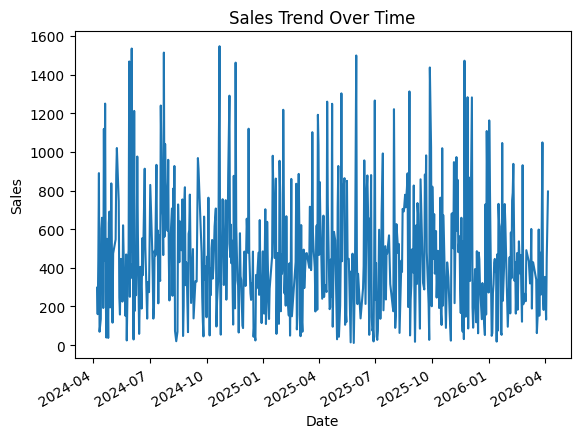

In [6]:
trend = df.groupby('Date')['Sales'].sum()

plt.figure()
trend.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

/tmp/ipykernel_6823/2134088132.py:10: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



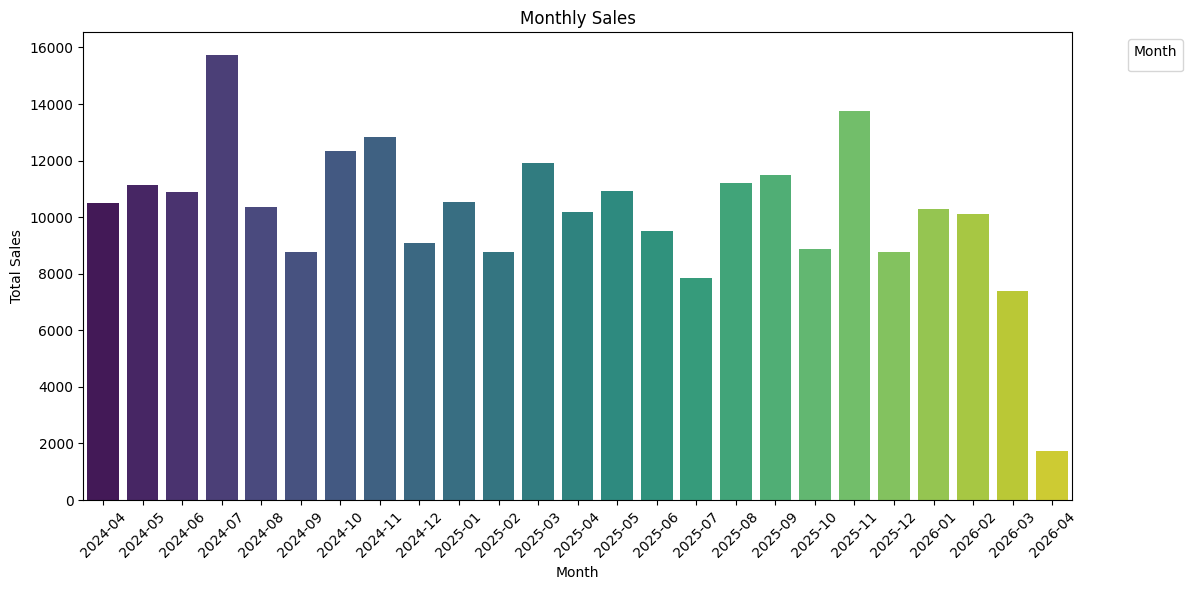

In [17]:
df['Month'] = df['Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Sales', data=monthly, hue='Month', dodge=False, palette='viridis')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6823/375022619.py:8: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



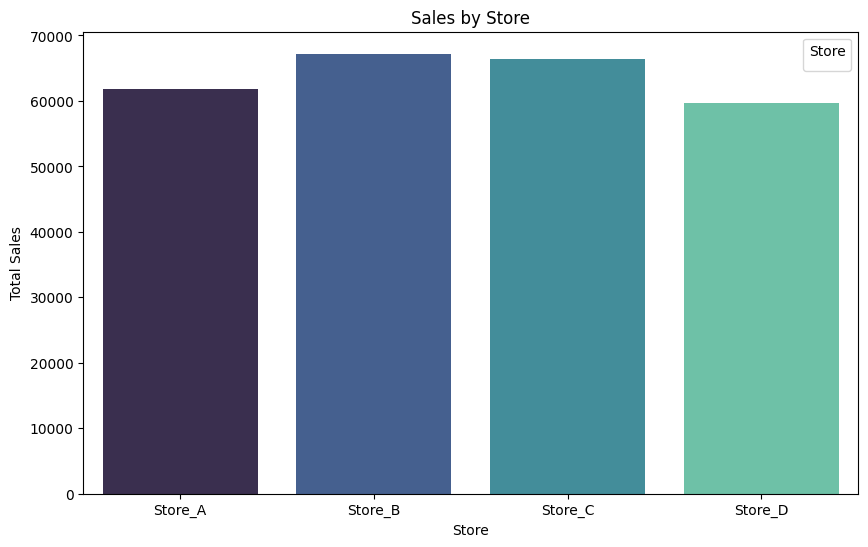

In [18]:
store_sales = df.groupby('Store')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Store', y='Sales', data=store_sales, hue='Store', dodge=False, palette='mako')
plt.title("Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.legend(title='Store')
plt.show()

/tmp/ipykernel_6823/3834531240.py:8: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



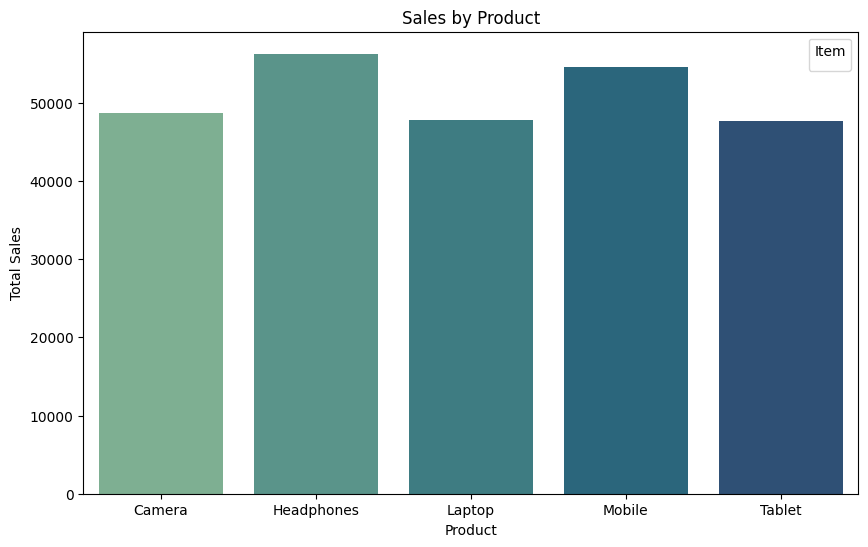

In [19]:
item_sales = df.groupby('Item')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Item', y='Sales', data=item_sales, hue='Item', dodge=False, palette='crest')
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.legend(title='Item')
plt.show()

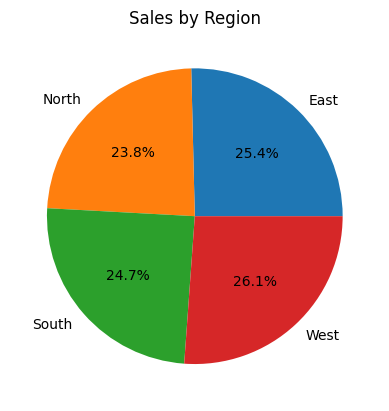

In [20]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')
plt.title("Sales by Region")
plt.show()

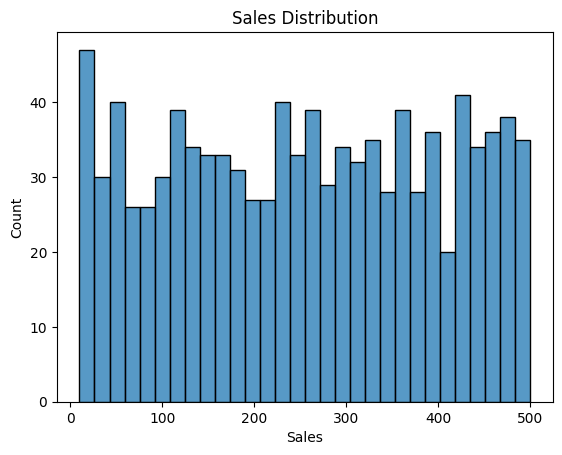

In [21]:
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

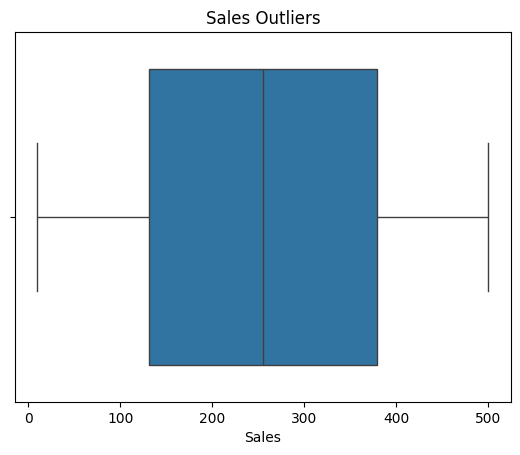

In [22]:
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

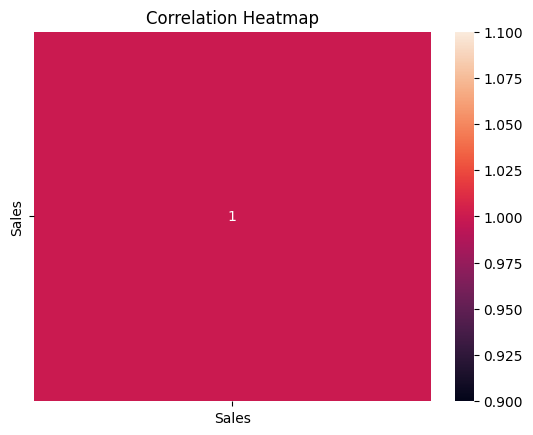

In [23]:
corr = df[['Sales']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
fig = px.line(trend, x=trend.index, y='Sales', title='Sales Trend')
fig.show()